In [1]:
import transformers
import torch
from datasets import load_dataset
import os 
import sys
from tqdm import tqdm

In [2]:
# from huggingface_hub import login
# login()

In [3]:
data_path = '/home/jizej/Workspaces/UOUO/keyword/ShareGPT4V'
if data_path not in sys.path:
    sys.path.append(data_path)
    
os.environ['PYTHONPATH'] = os.environ.get('PYTHONPATH', '') + f":{data_path}"
os.environ['HF_HOME'] = '/home/jizej/.cache/huggingface'
print(os.getenv('HF_HOME'))

/home/jizej/.cache/huggingface


In [4]:
ds = load_dataset("Lin-Chen/ShareGPT4V", "ShareGPT4V")

In [5]:
ds['train'][0]

{'id': '000000000009',
 'image': 'coco/train2017/000000000009.jpg',
 'conversations': [{'from': 'human',
   'value': 'What do you see happening in this image?\n<image>'},
  {'from': 'gpt',
   'value': "In the center of the image, a vibrant blue lunch tray holds four containers, each brimming with a variety of food items. The containers, two in pink and two in yellow, are arranged in a 2x2 grid.\n\nIn the top left pink container, a slice of bread rests, lightly spread with butter and sprinkled with a handful of almonds. The bread is cut into a rectangle, and the almonds are scattered across its buttery surface.\n\nAdjacent to it in the top right corner, another pink container houses a mix of fruit. Sliced apples with their fresh white interiors exposed share the space with juicy chunks of pineapple. The colors of the apple slices and pineapple chunks contrast beautifully against the pink container.\n\nBelow these, in the bottom left corner of the tray, a yellow container holds a single 

In [7]:
# create a subset of the the dataset with only COCO captions, since the dataset is small we can do this in RAM
coco_ds = ds.filter(lambda x: x['image'].startswith('coco'))

Filter:   0%|          | 0/102025 [00:00<?, ? examples/s]

In [9]:
data_path = '/home/jizej/Workspaces/UOUO/keyword/ShareGPT4V/data/'
sample = ds['train'][2]
image = os.path.join(data_path, sample['image'])
query = sample['conversations'][0]['value']
gpt_ans = sample['conversations'][1]['value']
print(gpt_ans)

The image presents a serene garden scene, centered around a white vase with a bouquet of flowers. The vase, exhibiting a fluted design and resting on a pedestal base, is placed on a white railing. It holds a bouquet of flowers, a harmonious blend of white and pink blossoms, interspersed with touches of greenery. 

The vase and its floral contents are the focal point of the image, captured from a slight angle that places them in the center of the frame. The background reveals a lush garden, populated with verdant plants and enclosed by a white fence. The overall composition exudes an atmosphere of tranquility and natural beauty.


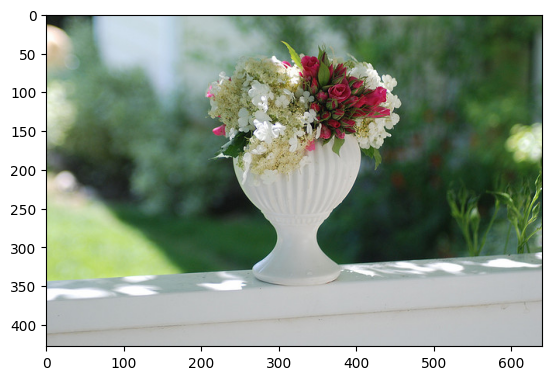

In [10]:
# show image
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(image)
plt.imshow(img)

In [11]:
llama_template_long = """
    I have the following conversation:
- Human: What do you see happening in this image? GPT: In the center of the image, there is a blue lunch tray with four containers filled with different types of food. The containers are two pink and two yellow, arranged in a 2x2 grid.
In the top left pink container, there is a slice of bread with butter and a scattering of almonds on top. The bread is cut into a rectangular shape, and the almonds are spread across it.
Next to it, in the top right pink container, there is a mix of fruit, including slices of apple and chunks of pineapple. The colors of the apple slices and pineapple pieces stand out against the pink container.
In the bottom left corner, a yellow container holds a single meatball and some broccoli. The meatball is round and browned, while the broccoli florets are bright green.
In the bottom right yellow container, there is a chocolate chip cookie. The cookie is golden-brown with dark chocolate chips spread across its surface.
Overall, the food is arranged neatly and appealingly on the blue tray, with each type of food in its own container, creating a balanced and colorful meal.

Please give me the keywords that are present in this conversation and separate them with commas.
Make sure you to only return the keywords and say nothing else. For example, don't say:
"Here are the keywords present in the conversation"
<|eot_id|><|start_header_id|>assistant<|end_header_id|> Lunch tray, Containers (pink, yellow), Bread with butter, Almonds, Sliced apples, Pineapple chunks, Meatball, Broccoli, Chocolate chip cookie, Blue tray, Food arrangement, 2x2 grid, Vibrant colors, Balanced meal<|eot_id|><|start_header_id|>user<|end_header_id|>
I have the following conversation:
- Human: {query} GPT: {gpt_ans}

Please give me the keywords that are present in this conversation and separate them with commas.
Make sure you to only return the keywords and say nothing else. For example, don't say:
"Here are the keywords present in the conversation<|eot_id|><|start_header_id|>assistant<|end_header_id|>"
"""

llama_template = """
Please give me the keywords that are present in this conversation and separate them with commas.
Make sure you to only return the keywords and say nothing else.
I have the following conversation:
- Human: {query} GPT: {gpt_ans}
"""

llama_prompt = llama_template.format(
        query=query,
        gpt_ans=gpt_ans
    )

print(llama_prompt)


Please give me the keywords that are present in this conversation and separate them with commas.
Make sure you to only return the keywords and say nothing else.
I have the following conversation:
- Human: What do you see happening in this image?
<image> GPT: The image presents a serene garden scene, centered around a white vase with a bouquet of flowers. The vase, exhibiting a fluted design and resting on a pedestal base, is placed on a white railing. It holds a bouquet of flowers, a harmonious blend of white and pink blossoms, interspersed with touches of greenery. 

The vase and its floral contents are the focal point of the image, captured from a slight angle that places them in the center of the frame. The background reveals a lush garden, populated with verdant plants and enclosed by a white fence. The overall composition exudes an atmosphere of tranquility and natural beauty.



In [12]:
# pipeline = transformers.pipeline(
#     "text-generation",
#     model=model_id,
#     model_kwargs={"torch_dtype": torch.bfloat16},
#     device_map="auto",
# )

# terminators = [
#     pipeline.tokenizer.eos_token_id,
#     pipeline.tokenizer.convert_tokens_to_ids("<|eot_id|>")
# ]

In [13]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import time


model_id = "meta-llama/Meta-Llama-3-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id, padding_side = "left")
tokenizer.pad_token_id = tokenizer.eos_token_id
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.bfloat16, device_map="auto")
terminators = [
    tokenizer.eos_token_id,
    tokenizer.convert_tokens_to_ids("<|eot_id|>")
]



Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [14]:
# messages = [
#     {"role": "system", "content": "You are a helpful chatbot that assists users in generating keywords from conversations. You have been given a conversation and need to generate keywords from it."},
#     {"role": "user", "content": llama_prompt },
# ]

# outputs = pipeline(
#     messages,
#     max_new_tokens=256,
#     eos_token_id=terminators,
#     do_sample=True,
#     temperature=0.6,
#     top_p=0.9,
# )
# print(outputs[0]["generated_text"][-1])

# print(outputs)

In [16]:
class PromptIterableDataset(torch.utils.data.IterableDataset):
    def __init__(self, ds, template):
        self.ds = ds
        self.template = template

    def __iter__(self):
        for sample in self.ds:
            query = sample['conversations'][0]['value']
            gpt_ans = sample['conversations'][1]['value']
            llama_prompt = self.template.format(
                query=query,
                gpt_ans=gpt_ans
            )
            messages = [
                {"role": "system", "content": "You are a helpful chatbot that assists users in generating keywords from conversations. You have been given a conversation and need to generate keywords from it."},
                {"role": "user", "content": llama_prompt },
            ]
            yield messages

class PromptDataset(torch.utils.data.Dataset):
    def __init__(self, ds, template):
        self.ds = ds
        self.template = template

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        sample = self.ds[idx]
        query = sample['conversations'][0]['value']
        gpt_ans = sample['conversations'][1]['value']
        llama_prompt = self.template.format(
            query=query,
            gpt_ans=gpt_ans
        )
        messages = [
            {"role": "system", "content": "You are a helpful chatbot that assists users in generating keywords from conversations. You have been given a conversation and need to generate keywords from it."},
            {"role": "user", "content": llama_prompt },
        ]
        return messages
    
prompt_ds = PromptDataset(coco_ds['train'], llama_template) # we use the subset of the dataset with COCO captions

output_dir = '/home/jizej/Workspaces/UOUO/keyword/ShareGPT4V/output/llama_sharegpt4v_keywords'
# create dir if not exists
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

prompt_loader = torch.utils.data.DataLoader(prompt_ds, batch_size=128, collate_fn=lambda x: [_ for _ in x], shuffle=False)

llama_keywords = []
for i, batch in enumerate(tqdm(prompt_loader)):
    texts = tokenizer.apply_chat_template(batch, add_generation_prompt=True, tokenize=False)
    inputs = tokenizer(texts, padding="longest", return_tensors="pt").to(model.device)
    # inputs = {key: val. for key, val in inputs.items()}
    temp_texts=tokenizer.batch_decode(inputs["input_ids"], skip_special_tokens=True)


    start_time = time.time()
    gen_tokens = model.generate(
        **inputs, 
        max_new_tokens=128, 
        pad_token_id=tokenizer.eos_token_id, 
        eos_token_id=terminators,
        do_sample=True,
        temperature=0.6,
        top_p=0.9
    )

    gen_text = tokenizer.batch_decode(gen_tokens, skip_special_tokens=True)
    gen_text = [i[len(temp_texts[idx]):] for idx, i in enumerate(gen_text)]

    llama_keywords.extend(gen_text)

    # write to file every 10 batches or at the end
    if i % 10 == 0 or i == len(prompt_loader) - 1:
        with open(os.path.join(output_dir, f"llama_keywords_{i}.txt"), "w") as f:
            f.write("\n".join(llama_keywords))
        llama_keywords = []

100%|██████████| 391/391 [1:53:08<00:00, 17.36s/it]


In [ ]:
llama_outputs